In [4]:
array1 = [1, 2, 3, "four"]
print(array1)
print(type(array1))

[1, 2, 3, 'four']
<class 'list'>


In [ ]:
import numpy as np # numeric python
# 1D array (one-dimensional)
array1d = np.array([1, 2, 3, 4, 5, 6])
print(array1d)
print(f"shape: {array1d.shape}")
print(type(array1d))

[1 2 3 4 5 6]
shape: (6,)
<class 'numpy.ndarray'>


In [6]:
# 2D array (two-dimensional)
array2d = np.array([[1, 2, 3],
                    [4, 5, 6]])
print(array2d)
print(f"shape: {array2d.shape}")
print(type(array2d))

[[1 2 3]
 [4 5 6]]
shape: (2, 3)
<class 'numpy.ndarray'>


In [9]:
# 3D array
array3d = np.array([[[255, 0, 0], [0, 255, 0], [0, 0, 255]], 
                    [[0, 0, 255], [0, 255, 0], [255, 0, 0]]])

print(array3d)
print(f"shape: {array3d.shape}")
print(type(array3d))

[[[255   0   0]
  [  0 255   0]
  [  0   0 255]]

 [[  0   0 255]
  [  0 255   0]
  [255   0   0]]]
shape: (2, 3, 3)
<class 'numpy.ndarray'>


In [ ]:
# length of inner lists must be the same length, otherwise there will be an error
array_with_error = np.array([[1, 2, 3], [4, 5]])

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

In [12]:
from ugot import ugot
got = ugot.UGOT()
got.initialize("192.168.1.199")

192.168.1.199:50051


The camera is on.
The raw data: b'\xff\xd8\xff\xdb\x00C\x00\t\x05\x06\x07\x06\x05\t\x07\x06\x07\n\t\t\n\r\x16\x0e\r\x0c\x0c\r\x1b\x13\x14\x0f\x16 \x1c!!\x1f\x1c\x1f\x1e$(3+$&0&\x1e\x1f-<-0479:9"*?C?8C3897\xff\xdb\x00C\x01\t\n\n\r\x0b\r\x19\x0e\x0e\x197%\x1f%77777777777777777777777777777777777777777777777777\xff\xc0\x00\x11\x08\x01\xe0\x02\x80\x03\x01!\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1f\x00\x00\x01\x05\x01\x01\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b\xff\xc4\x00\xb5\x10\x00\x02\x01\x03\x03\x02\x04\x03\x05\x05\x04\x04\x00\x00\x01}\x01\x02\x03\x00\x04\x11\x05\x12!1A\x06\x13Qa\x07"q\x142\x81\x91\xa1\x08#B\xb1\xc1\x15R\xd1\xf0$3br\x82\t\n\x16\x17\x18\x19\x1a%&\'()*456789:CDEFGHIJSTUVWXYZcdefghijstuvwxyz\x83\x84\x85\x86\x87\x88\x89\x8a\x92\x93\x94\x95\x96\x97\x98\x99\x9a\xa2\xa3\xa4\xa5\xa6\xa7\xa8\xa9\xaa\xb2\xb3\xb4\xb5\xb6\xb7\xb8\xb9\xba\xc2\xc3\xc4\xc5\xc6\xc7\xc8\xc9\xca\xd2\xd3\xd4\xd5\xd6\xd7\xd8\xd9\xda\xe1\xe2\xe3\xe4\xe5\xe6\

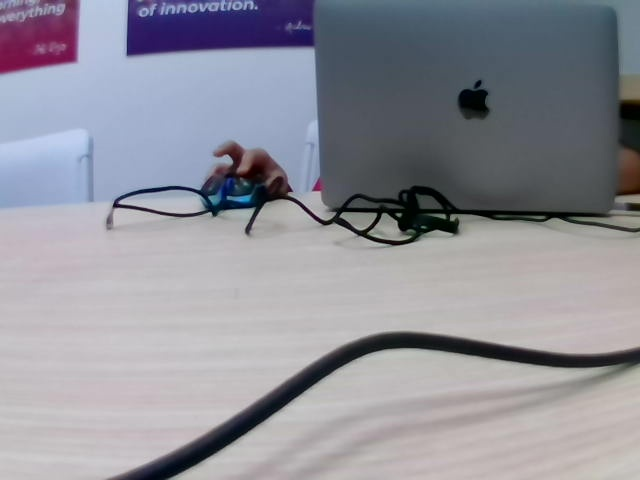

In [19]:
import cv2
from IPython.display import Image, display

# Step 1: turn on the camera
got.open_camera()
print("The camera is on.")

# Step 2: get the raw data
picture = got.read_camera_data()
print(f"The raw data: {picture}")
print(f"Data type: {type(picture)}\n")

# Step 3: unpack the raw data, change from bytes to 1D array
picture = np.frombuffer(picture, np.uint8)
print(f"Data after step 3: {picture}")
print(f"Shape: {picture.shape}")
print(f"Data type: {type(picture)}\n")

# Step 4: 1D array to 3D array
picture = cv2.imdecode(picture, cv2.IMREAD_COLOR)
print(f"Data after step 4: {picture}")
print(f"Shape: {picture.shape}")
print(f"Data type: {type(picture)}\n")

# Step 5: pack the 3D array as .jpg
ok, picture_jpg = cv2.imencode(".jpg", picture)
print(f"Data after step 5: {picture_jpg}")
print(f"Shape: {picture_jpg.shape}")
print(f"Data type: {type(picture_jpg)}\n")

# Step 6: show the image on screen
display(Image(picture_jpg.tobytes()))

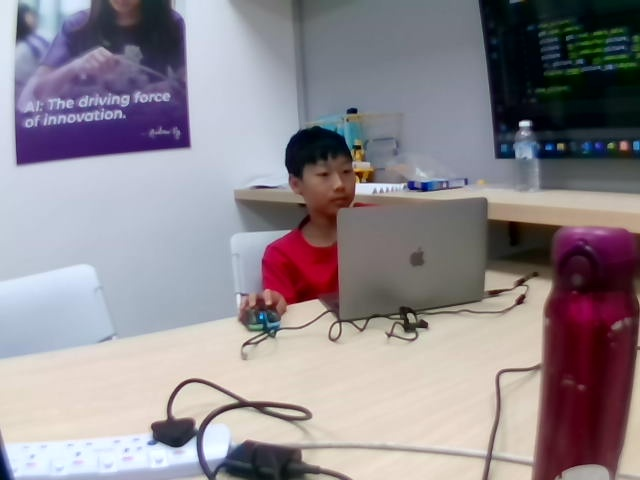

In [21]:
def show_picture():
    got.open_camera()
    picture = got.read_camera_data()
    picture = np.frombuffer(picture, np.uint8)
    picture = cv2.imdecode(picture, cv2.IMREAD_COLOR)
    ok, picture_jpg = cv2.imencode(".jpg", picture)
    display(Image(picture_jpg.tobytes()))

show_picture()